In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Activation,BatchNormalization,Input,Embedding,Dot,Dense,Flatten
from tensorflow.keras.callbacks import ModelCheckpoint,LearningRateScheduler,TensorBoard,EarlyStopping

from wordcloud import WordCloud
%matplotlib inline

2.20.0


# READING ANIMELIST.CSV 

In [9]:
import os

In [10]:
INPUT_DIR = os.path.join("..","artifacts","raw")

In [11]:
rating_df = pd.read_csv(INPUT_DIR+"/animelist.csv" , low_memory=True,usecols=["user_id","anime_id","rating"])

In [12]:
rating_df.head()

,user_id,anime_id,rating
0,0,67,9
1,0,6702,7
2,0,242,10
3,0,4898,0
4,0,21,10


In [ ]:
rating_df.length()

In [14]:
len(rating_df)

5000000

# DATA PROCESSING

#### STRIP THE DATA TO ONLY USERS WITH MORE THAN 400 NUMBER OF RATINGS

In [49]:
# Check the users and how many ratings they have given

n_ratings = rating_df["user_id"].value_counts()
rating_df = rating_df[rating_df["user_id"].isin(n_ratings[n_ratings>=400].index)].copy()

In [154]:
n_ratings
# n_ratings[n_ratings >= 400]

user_id
11100    14429
10255     8403
4773      5735
6852      5406
16057     5080
         ...  
10675      400
8213       400
4529       400
8812       400
4125       400
Name: count, Length: 4203, dtype: int64

In [155]:
len(rating_df)

3246641

In [ ]:
rating_df = rating_df[rating_df["user_id"].isin(n_ratings[n_ratings>=400].index)].copy()
# This determines the number of user IDs with ratings more than or equal to 400

In [53]:
rating_df

,user_id,anime_id,rating
213,2,24833,0.0
214,2,235,0.1
215,2,36721,0.0
216,2,40956,0.0
217,2,31933,0.0
...,...,...,...
4999916,16507,8985,0.0
4999917,16507,5454,0.0
4999918,16507,15911,0.0
4999919,16507,878,0.0


In [54]:
len(rating_df)
# As you can see, the dataset is stripped down by 2m, which are the people with number of ratings less than 400

3246641

#### DOWNSCALE THE RATING FROM RANGE 0-10 TO 0-1

In [55]:
min_rating = min(rating_df["rating"])

In [56]:
min_rating

0.0

In [57]:
max_rating = max(rating_df["rating"])

In [58]:
max_rating

0.1

In [48]:
min_rating

0.0

In [59]:
avg_rating =np.mean(rating_df["rating"])

In [60]:
avg_rating

np.float64(0.04122732695114735)

In [61]:
# Scaling down features to make the rating scale down from 0 to 1, instead of 0 to 10. This is called min_max scaling
rating_df["rating"] = rating_df["rating"].apply(lambda x: (x-min_rating)/(max_rating-min_rating)).values.astype(np.float64)

In [62]:
min_rating = min(rating_df["rating"])
min_rating

0.0

In [64]:
max_rating = max(rating_df["rating"])
max_rating

1.0

In [65]:
avg_rating =np.mean(rating_df["rating"])
avg_rating

np.float64(0.4122732695114735)

In [66]:
# As you can see, we have only scaled down the ratings feature, the relationships between features and every other thing remains intact.

#### CHECK FOR DUPLICATES

In [67]:
rating_df.duplicated().sum()

np.int64(0)

In [68]:
rating_df.isnull().sum()

user_id     0
anime_id    0
rating      0
dtype: int64

#### ENCODE SOME OF THE FEATURES

In [ ]:
# Grab the list of unique user ids, encode and decode, create a new column (User) for the encoding
user_ids = rating_df["user_id"].unique().tolist()
user2user_encoded = {x : i for i , x in enumerate(user_ids)}
user2user_decoded = {i : x for i , x in enumerate(user_ids)}
rating_df["user"] = rating_df["user_id"].map(user2user_encoded)

In [71]:
n_users = len(user2user_encoded)

In [72]:
n_users

4203

In [73]:
# Do exact same as above for anime_id
anime_ids = rating_df["anime_id"].unique().tolist()
anime2anime_encoded = {x : i for i , x in enumerate(anime_ids)}
anime2anime_decoded = {i : x for i , x in enumerate(anime_ids)}
rating_df["anime"] = rating_df["anime_id"].map(anime2anime_encoded)

In [74]:
n_anime = len(anime2anime_encoded)

In [75]:
n_anime

17149

#### INTRODUCE RANDOMNESS TO PREVENT DATA LEAKAGE, AND TO LEARN FROM THAT RANDOMNESS, SO ORDER DOESN'T CAUSE BIAS

In [ ]:
rating_df = rating_df.sample(frac=1,random_state=43).reset_index(drop=True)
# 1. rating_df.sample(frac=1, random_state=43)

# .sample(frac=1) → means take 100% of the rows, but in random order.

# frac=1 = fraction of rows to sample = 100%.

# Effectively, this shuffles all rows in the DataFrame.

# random_state=43 → sets a fixed random seed so the shuffle is reproducible (you’ll get the same random order every time you run it)

# 2. .reset_index(drop=True)

# This resets the index to a clean, sequential 0-based order:
# Without drop=True, the old index (2, 0, 1) would be added as a new column called index.

# With drop=True, pandas discards that old index entirely.

In [76]:
rating_df.head(2)

,user_id,anime_id,rating,user,anime
213,2,24833,0.0,0,0
214,2,235,1.0,0,1


In [ ]:
#Splitting into input and output data. Note: .values converts the data into a numpy array as the model can only accept arrays
X = rating_df[["user","anime"]].values
y = rating_df["rating"]

In [ ]:
#specify the size of test data to prepare it for splitting into test and training data
test_size = 1000

#Subtract it from total data to get the training data size
#W DataFrame.shape returns a tuple: (number_of_rows, number_of_columns) So: .shape[0] → number of rows, .shape[1] → number of columns
# in this case you are subtracting 1000 rows from number of rows
train_indices = rating_df.shape[0] - test_size


In [81]:
X_train , X_test , y_train , y_test = (
    X[:train_indices],
    X[train_indices :],
    y[:train_indices],
    y[train_indices:],
)

In [82]:
len(X_train)

3245641

In [83]:
len(X_test)

1000

In [85]:
#Check if our data is a numpy array because the nmodel only accepts numpy array
type(X_train)

numpy.ndarray

In [ ]:
#Create two separate arrays: one for anime features and one for user features, all stored in a list across both test and traininfg data
# To separate the user fron anime
X_train_array = [X_train[: , 0] , X_train[: ,1]]
X_test_array = [X_test[: , 0] , X_test[: ,1]]



In [89]:
type(X_test_array)

list

In [90]:
type(X_train_array)

list

In [92]:
type(X_train_array[0])

numpy.ndarray

In [ ]:
#In x_train array, the users are in the first block of the list, and anime ate in the second block. This is the same for x_test_array


# MODEL ARCHITECTURE

In [ ]:
def RecommenderNet():
    #Each user and each anime will be represented as a 128-dimensional vector...so it has 128 long space to learn and output features of users and animes
    embedding_size =128
    #Input layer for user ID....shape=[1] means each input contains one integer (encoded user ID)
    user = Input(name="user",shape=[1])

    #input_dim=n_users → total number of unique user IDs; output_dim=128 → each user gets a 128-length preference vector
    user_embedding = Embedding(name="user_embedding",input_dim=n_users,output_dim=embedding_size)(user)

     #Input layer for anime ID....shape=[1] means each input contains one integer (encoded anime ID)
    anime = Input(name="anime",shape=[1])

    # Same as input embedding layer above. (user) or (anime) at the end calls the embedding layer as a function and passes the user or anime as variable to produce profile vectors for that user or anime.
    anime_embedding = Embedding(name="anime_embedding",input_dim=n_anime,output_dim=embedding_size)(anime)

    #Dot compares the user vector with the anime vector. If the user’s interests match the anime’s traits → high similarity, If not → low similarity
    #Normalise=True, normalises the vectors before comparing(Dot), making it equivalent to cosine similarities
    x = Dot(name="dot_product" , normalize=True , axes=2)([user_embedding,anime_embedding])

    #Dot product outputs a tensor like [[0.85]]. Flatten turns it into a simple scalar number
    x = Flatten()(x)

    #A fully connected layer that transforms similarity into a rating.
    x = Dense(1,kernel_initializer='he_normal')(x)

    #This normalizes the output before the final activation
    x = BatchNormalization()(x)

    #Sigmoid converts output to a number between 0 and 1.This matches your normalized ratings (0 → low, 1 → high).
    x = Activation("sigmoid")(x)

    #Defining the model
    model = Model(inputs=[user,anime], outputs=x)

    #binary_crossentropy → suitable for values between 0 and 1 ( for loss function: loss = binary_crossentropy(true_rating, predicted_rating), to calculate the loss between true value and predicted value)
    # mae → mean absolute error
    # mse → mean squared error
    # Adam → a very popular optimizer for neural networks
    model.compile(loss="binary_crossentropy",metrics=["mae","mse"],optimizer='Adam')
    return model

In [94]:
model = RecommenderNet()

In [95]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user (InputLayer)   │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 128)    │    537,984 │ user[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anime_embedding     │ (None, 1, 128)    │  2,195,072 │ anime[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_product (Dot)   │ (None, 1, 1)      │          0 │ user_embedding[0… │
│                     │                   │            │ anime_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1)         │          0 │ dot_product[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │          2 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1)         │          4 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1)         │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,733,062 (10.43 MB)

 Trainable params: 2,733,060 (10.43 MB)

 Non-trainable params: 2 (8.00 B)

### Define Learning Rate 

In [ ]:
# Find the best learning rate for your model. Controls how fast the model learns during training.Learning rate is how big each weight update step is.
start_lr = 0.00001
min_lr = 0.0001
max_lr = 0.00005
batch_size = 10000 #smoother updates, but more memory required

ramup_epochs = 5 #first few epochs during which learning rate ramps up from start_lr to max_lr
sustain_epochs = 0 #how long to keep max_lr constant (0 here → skip this step).
exp_decay = 0.8 #exponential decay factor used after ramp-up to gradually reduce learning rate.

def lrfn(epoch):
    if epoch<ramup_epochs:
        return (max_lr-start_lr)/ramup_epochs*epoch + start_lr  #Linearly increase learning rate from start_lr → max_lr.Helps warm up the training, avoiding unstable updates at the start.
    elif epoch<ramup_epochs+sustain_epochs:
        return max_lr #Keep learning rate constant at max_lr for a few epochs. Not used here (sustain_epochs=0).
    else:
        return (max_lr-min_lr) * exp_decay ** (epoch-ramup_epochs-sustain_epochs)+min_lr #Gradually reduce learning rate over time. exp_decay controls how quickly it decreases.+ min_lr ensures it never goes below a minimum value

### Define Callbacks

In [ ]:
#Get the callbacks. Purpose: Dynamically changes the learning rate during training based on the epoch.
# LearningRateScheduler takes a function that outputs the learning rate for each epoch.
# Here, it uses your previously defined lrfn(epoch) function.
# verbose=0 → don’t print the learning rate at each epoch.

lr_callback = LearningRateScheduler(lambda epoch:lrfn(epoch) , verbose=0)

#Where to save the model weights.
checkpoint_filepath = './weights.weights.h5'

#Purpose: Save the best version of the model while training.
# | Parameter                | Meaning                                                        |
# | ------------------------ | -------------------------------------------------------------- |
# | `filepath`               | Where to save the model weights.                               |
# | `save_weights_only=True` | Only save weights, not the full model.                         |
# | `monitor="val_loss"`     | Track the validation loss to decide if this is the best model. |
# | `mode="min"`             | Look for the **lowest** validation loss (smaller is better).   |
# | `save_best_only=True`    | Only overwrite the file if the model improved.                 |
model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath,save_weights_only=True,monitor="val_loss",mode="min",save_best_only=True)

#Purpose: Stop training if the model stops improving.
# | Parameter                   | Meaning                                                                                 |
# | --------------------------- | --------------------------------------------------------------------------------------- |
# | `patience=3`                | Wait for 3 epochs without improvement before stopping.                                  |
# | `monitor="val_loss"`        | Check validation loss to determine improvement.                                         |
# | `mode="min"`                | We want to minimize the loss.                                                           |
# | `restore_best_weights=True` | After stopping, restore the weights from the epoch with the **lowest validation loss**. |

early_stopping = EarlyStopping(patience=3,monitor="val_loss",mode="min",restore_best_weights=True)

In [98]:
my_callbacks = [model_checkpoint,lr_callback,early_stopping]

########################################### SIDE NOTE #############################################################################
### How does .fit() train the model?

When you write:

model.fit(X_train_array, y_train, ...)


you are telling the neural network:

“Here are examples (inputs X), and here are the correct answers (y).
Learn how to predict y from X.”

Think of .fit() like teaching a child
#### Step 1 — Show an example

Input: (user_id, anime_id)
Target output: the rating (0 to 1 after normalization)

#### Step 2 — The model makes a prediction

e.g.
The model predicts:

Predicted rating: 0.62


But the true rating is:

True rating: 0.90

#### Step 3 — Calculate the error

This uses your loss function:

loss = binary_crossentropy(true_rating, predicted_rating)

#### Step 4 — Adjust the weights

The optimizer (Adam) changes the embedding vectors and dense layer weights so predictions become more accurate next time.

This process happens:

for every batch

for every epoch

So .fit() is just:

Looping over your training examples
→ predicting
→ checking mistakes
→ improving the model.

🏗️ Specifically for your model

Your model contains:

user embedding (trainable)

anime embedding (trainable)

dot product layer

dense layer

.fit() updates all of these so they represent meaningful patterns.

########################################################################################################################################

In [ ]:
# The weights being adjusted based on our scenario are: 
# | Layer                     | Type of weights                                  |
# | ------------------------- | ------------------------------------------------ |
# | User Embedding            | Vector representing each user                    |
# | Anime Embedding           | Vector representing each anime                   |
# | Dot / Dense layers        | Connection weights between embeddings and output |
# | BatchNormalization        | Scaling & shifting parameters                    |
# | Dense layer kernel & bias | Learn final mapping to output                    |

In [ ]:
# | Part              | Meaning                                                     |
# | ----------------- | ----------------------------------------------------------- |
# | `.fit()`          | Trains the model                                            |
# | `X_train_array`   | Inputs (user, anime)                                        |
# | `y_train`         | True ratings                                                |
# | `batch_size`      | Number of samples processed before weight update            |
# | `epochs`          | How many times to see whole dataset                         |
# | `validation_data` | Checks generalization                                       |
# | `callbacks`       | Automates training (LR schedule, checkpointing, early stop) |
# | `history`         | Contains metrics for plotting and analysis                  |

history = model.fit(
    x=X_train_array,
    y=y_train,
    batch_size=batch_size,
    epochs=20,
    verbose=1,
    validation_data = (X_test_array,y_test),
    callbacks=my_callbacks
)

Epoch 1/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.7881 - mae: 0.3800 - mse: 0.1934 - val_loss: 0.7034 - val_mae: 0.2894 - val_mse: 0.1205 - learning_rate: 1.0000e-05
Epoch 2/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7847 - mae: 0.3787 - mse: 0.1920 - val_loss: 0.7592 - val_mae: 0.3149 - val_mse: 0.1432 - learning_rate: 1.8000e-05
Epoch 3/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7790 - mae: 0.3766 - mse: 0.1897 - val_loss: 0.7731 - val_mae: 0.3201 - val_mse: 0.1481 - learning_rate: 2.6000e-05
Epoch 4/20
325/325 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7709 - mae: 0.3734 - mse: 0.1864 - val_loss: 0.7718 - val_mae: 0.3197 - val_mse: 0.1476 - learning_rate: 3.4000e-05


In [ ]:
#This callback automatically saved the BEST model weights during training — specifically the version with the lowest validation loss. 
# This command ensures the model you use afterward (for predictions) is the best-performing version, not just the last-trained version
model.load_weights(checkpoint_filepath)

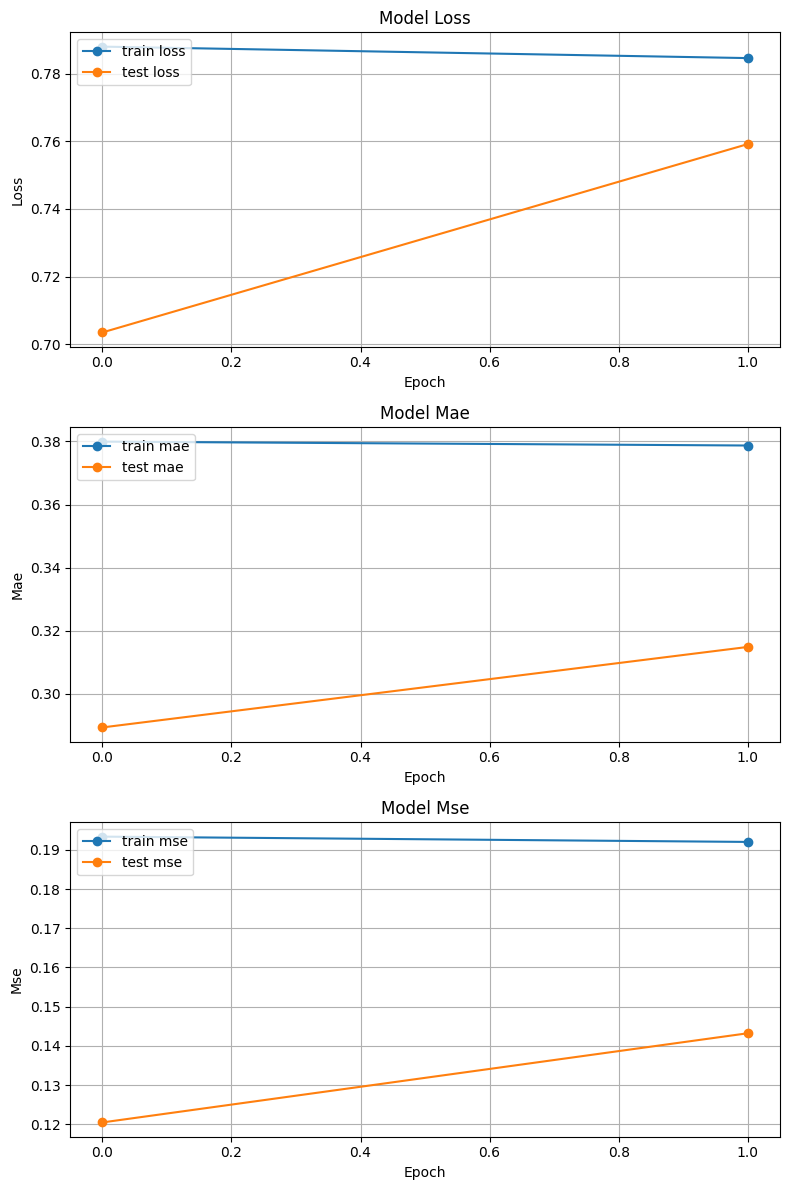

In [101]:
metrics = ["loss", "mae", "mse"]

# Create subplots
fig, axes = plt.subplots(len(metrics), 1, figsize=(8, len(metrics) * 4))

for i, metric in enumerate(metrics):
    ax = axes[i]
    ax.plot(history.history[metric][0:-2], marker="o", label=f"train {metric}")
    ax.plot(history.history[f"val_{metric}"][0:-2], marker="o", label=f"test {metric}")
    ax.set_title(f"Model {metric.capitalize()}")
    ax.set_ylabel(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend(loc="upper left")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
def extract_weights(name,model):
    weight_layer = model.get_layer(name)
    weights = weight_layer.get_weights()[0]
    weights = weights/np.linalg.norm(weights,axis=1).reshape((-1,1))
    return weights

In [103]:
anime_weights = extract_weights("anime_embedding",model)

In [104]:
user_weights = extract_weights("user_embedding",model)

### READ ANIME.CSV

In [105]:
df = pd.read_csv(INPUT_DIR+"/anime.csv",low_memory=True)
df.head(2)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-10,Score-9,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,229170.0,182126.0,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space",Cowboy Bebop:The Movie,カウボーイビバップ 天国の扉,Movie,1,"Sep 1, 2001",Unknown,...,30043.0,49201.0,49505.0,22632.0,5805.0,1877.0,577.0,221.0,109.0,379.0


In [ ]:
#This line searches the entire DataFrame for the value "Unknown" and replaces every occurrence with NaN (Not a Number), which is how pandas represents missing data
df = df.replace("Unknown",np.nan)

In [ ]:
##Given an anime_id, it tries to return the English name of that anime. If the English name is missing, it falls back to the original Name
def getAnimeName(anime_id):
    try:
        name = df[df.anime_id == anime_id].eng_version.values[0]
        if name is np.nan:
            name = df[df.anime_id == anime_id].Name.values[0]
    except:
        print("Error")
    return name

In [ ]:
#Create anime_id from MAL_ID and also english_version from English_name
df["anime_id"] = df["MAL_ID"]
df["eng_version"] = df["English name"] #This creates another new column called eng_version, copying the existing English name column
df["eng_version"] = df.anime_id.apply(lambda x:getAnimeName(x)) #This line overwrites the eng_version column from line 2

# Why overwrite the colum twice???
# Line 2 gives a base value:
# Line 3 then replaces it with the output of a custom function created earlier that:
# fixes missing values
# handles fallback logic
# ensures there is always some title to use later (important for your recommender output)
# This ensures eng_version is 100% populated and consistent.

In [ ]:
df.head(1)
# you can see anime_id and eng_version columns have been created

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space",Cowboy Bebop,カウボーイビバップ,TV,26,"Apr 3, 1998 to Apr 24, 1999",Spring 1998,...,131625.0,62330.0,20688.0,8904.0,3184.0,1357.0,741.0,1580.0,1,Cowboy Bebop


In [109]:
getAnimeName(6702)

'Fairy Tail'

In [ ]:
#Sort anime by Score by highest to lowest
#It sorts your dataframe df by the column Score, placing the highest scoring anime first.
df.sort_values(by=["Score"],
               inplace=True,
               ascending=False,
               kind="quicksort",
               na_position="last")

In [115]:
df.head(3)

,MAL_ID,Name,Score,Genres,English name,Japanese name,Type,Episodes,Aired,Premiered,...,Score-8,Score-7,Score-6,Score-5,Score-4,Score-3,Score-2,Score-1,anime_id,eng_version
3971,5114,Fullmetal Alchemist: Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",Fullmetal Alchemist:Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,TV,64,"Apr 5, 2009 to Jul 4, 2010",Spring 2009,...,199160.0,70045.0,20210.0,9308.0,3222.0,1536.0,2162.0,16806.0,5114,Fullmetal Alchemist:Brotherhood
15926,40028,Shingeki no Kyojin: The Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",Attack on Titan Final Season,進撃の巨人 The Final Season,TV,16,"Dec 7, 2020 to ?",Winter 2021,...,26016.0,8793.0,2674.0,1336.0,588.0,382.0,514.0,11061.0,40028,Attack on Titan Final Season
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",Steins;Gate,STEINS;GATE,TV,24,"Apr 6, 2011 to Sep 14, 2011",Spring 2011,...,140914.0,57740.0,21375.0,11126.0,5061.0,2292.0,1678.0,5255.0,9253,Steins;Gate


In [114]:
df.columns

Index(['MAL_ID', 'Name', 'Score', 'Genres', 'English name', 'Japanese name',
       'Type', 'Episodes', 'Aired', 'Premiered', 'Producers', 'Licensors',
       'Studios', 'Source', 'Duration', 'Rating', 'Ranked', 'Popularity',
       'Members', 'Favorites', 'Watching', 'Completed', 'On-Hold', 'Dropped',
       'Plan to Watch', 'Score-10', 'Score-9', 'Score-8', 'Score-7', 'Score-6',
       'Score-5', 'Score-4', 'Score-3', 'Score-2', 'Score-1', 'anime_id',
       'eng_version'],
      dtype='object')

In [116]:
#Reduce the number of colummns
df = df[["anime_id" , "eng_version","Score","Genres","Episodes","Type","Premiered","Members"]]

In [117]:
df.head(5)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
3971,5114,Fullmetal Alchemist:Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Ma...",64,TV,Spring 2009,2248456
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",24,TV,Spring 2011,1771162
14963,38524,Attack on Titan Season 3 Part 2,9.1,"Action, Drama, Fantasy, Military, Mystery, Sho...",10,TV,Spring 2019,1073626
9913,28977,Gintama Season 4,9.1,"Action, Comedy, Historical, Parody, Samurai, S...",51,TV,Spring 2015,404121


In [118]:
#Write a function to cater to if anime is passed in as integer(anime_id) or as string (anime_name)
def getAnimeFrame(anime,df):
    if isinstance(anime,int):
        return df[df.anime_id == anime]
    if isinstance(anime,str):
        return df[df.eng_version == anime]
    

In [119]:
#test it
getAnimeFrame(40028 , df)


,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
15926,40028,Attack on Titan Final Season,9.17,"Action, Military, Mystery, Super Power, Drama,...",16,TV,Winter 2021,733260


In [120]:
getAnimeFrame("Steins;Gate",df)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
5683,9253,Steins;Gate,9.11,"Thriller, Sci-Fi",24,TV,Spring 2011,1771162


### READ ANIME_WITH_SYNOPSIS.CSV

In [ ]:
# Define the columns you want
cols = ["MAL_ID","Name","Genres","sypnopsis"]

In [123]:
synopsis_df = pd.read_csv(INPUT_DIR+"/anime_with_synopsis.csv",usecols=cols)

In [125]:
synopsis_df.head(5)

,MAL_ID,Name,Genres,sypnopsis
0,1,Cowboy Bebop,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."
2,6,Trigun,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0..."
3,7,Witch Hunter Robin,"Action, Mystery, Police, Supernatural, Drama, ...",ches are individuals with special powers like ...
4,8,Bouken Ou Beet,"Adventure, Fantasy, Shounen, Supernatural",It is the dark century and the people are suff...


In [159]:
synopsis_df.columns

Index(['MAL_ID', 'Name', 'Genres', 'sypnopsis'], dtype='object')

In [ ]:
#I see what you’re trying to do: a function to fetch the synopsis either by MAL_ID (integer) or Name (string).
def getSynopsis(anime,synopsis_df):
    if isinstance(anime,int):
        return synopsis_df[synopsis_df.MAL_ID == anime].sypnopsis.values[0]
    if isinstance(anime,str):
        return synopsis_df[synopsis_df.Name == anime].sypnopsis.values[0]

In [132]:
getSynopsis(40028 , synopsis_df)

"Gabi Braun and Falco Grice have been training their entire lives to inherit one of the seven titans under Marley's control and aid their nation in eradicating the Eldians on Paradis. However, just as all seems well for the two cadets, their peace is suddenly shaken by the arrival of Eren Yeager and the remaining members of the Survey Corps. Having finally reached the Yeager family basement and learned about the dark history surrounding the titans, the Survey Corps has at long last found the answer they so desperately fought to uncover. With the truth now in their hands, the group set out for the world beyond the walls. In Shingeki no Kyojin: The Final Season , two utterly different worlds collide as each party pursues its own agenda in the long-awaited conclusion to Paradis' fight for freedom."

In [133]:
getSynopsis("Steins;Gate",synopsis_df)

'The self-proclaimed mad scientist Rintarou Okabe rents out a room in a rickety old building in Akihabara, where he indulges himself in his hobby of inventing prospective "future gadgets" with fellow lab members: Mayuri Shiina, his air-headed childhood friend, and Hashida Itaru, a perverted hacker nicknamed "Daru." The three pass the time by tinkering with their most promising contraption yet, a machine dubbed the "Phone Microwave," which performs the strange function of morphing bananas into piles of green gel. Though miraculous in itself, the phenomenon doesn\'t provide anything concrete in Okabe\'s search for a scientific breakthrough; that is, until the lab members are spurred into action by a string of mysterious happenings before stumbling upon an unexpected success—the Phone Microwave can send emails to the past, altering the flow of history. Adapted from the critically acclaimed visual novel by 5pb. and Nitroplus, Steins;Gate takes Okabe through the depths of scientific theory 

### CONTENT/ITEM BASED RECOMMENDATION

In [ ]:
# None means show full text of synopsis

pd.set_option("max_colwidth",None)


In [ ]:
def find_similar_animes(name, anime_weights, anime2anime_encoded, anime2anime_decoded, df, synopsis_df, n=10, return_dist=False, neg=False):
    # Get the anime_id for the given name
    index = getAnimeFrame(name, df).anime_id.values[0]
    encoded_index = anime2anime_encoded.get(index)

    if encoded_index is None:
        raise ValueError(f"Encoded index not found for anime ID: {index}")

    weights = anime_weights

    # Compute the similarity distances
    dists = np.dot(weights, weights[encoded_index])  # Ensure weights[encoded_index] is a 1D array
    sorted_dists = np.argsort(dists)

    n = n + 1

    # Select closest or farthest based on 'neg' flag
    if neg:
        closest = sorted_dists[:n]
    else:
        closest = sorted_dists[-n:]

    # Return distances and closest indices if requested
    if return_dist:
        return dists, closest

    # Build the similarity array
    SimilarityArr = []
    for close in closest:
        decoded_id = anime2anime_decoded.get(close)
       

       
        anime_frame = getAnimeFrame(decoded_id, df)

        anime_name = anime_frame.eng_version.values[0]
        genre = anime_frame.Genres.values[0]
        similarity = dists[close]
   

        SimilarityArr.append({
            "anime_id": decoded_id,
            "name": anime_name,
            "similarity": similarity,
            "genre": genre,
        })
       

    # Create a DataFrame with results and sort by similarity
    Frame = pd.DataFrame(SimilarityArr).sort_values(by="similarity", ascending=False)
    return Frame[Frame.anime_id != index].drop(['anime_id'], axis=1)


In [137]:
find_similar_animes(
    "Steins;Gate",
    anime_weights,
    anime2anime_encoded,
    anime2anime_decoded,
    df,
    synopsis_df,
)

,name,similarity,genre
9,Hatoya,0.320495,"Dementia, Music"
8,Yakata: Kannou Kitan,0.318027,Hentai
7,Tumulus Gal Coffy:the 12 Angry Tumuli,0.313094,Comedy
6,Watch Me Sink My Putz,0.302734,"Hentai, Sports"
5,Cleaning Switch,0.297557,Music
4,Queen's Blade: Grimoire,0.289259,"Action, Adventure, Ecchi, Fantasy"
3,Doura,0.288895,Hentai
2,Form of Stress,0.286000,Mecha
1,Superdimensional Romanesque Samy:Missing 99,0.285889,"Action, Sci-Fi"
0,Rainbow no Anime Bako,0.285077,Kids


### USER BASED RECOMMENDATION

In [138]:
def find_similar_users(item_input , user_weights , user2user_encoded , user2user_decoded, n=10 , return_dist=False,neg=False):
    try:
        index=item_input
        encoded_index = user2user_encoded.get(index)

        weights = user_weights

        dists = np.dot(weights,weights[encoded_index])
        sorted_dists = np.argsort(dists)

        n=n+1

        if neg:
            closest = sorted_dists[:n]
        else:
            closest = sorted_dists[-n:]
            

        if return_dist:
            return dists,closest
        
        SimilarityArr = []

        for close in closest:
            similarity = dists[close]

            if isinstance(item_input,int):
                decoded_id = user2user_decoded.get(close)
                SimilarityArr.append({
                    "similar_users" : decoded_id,
                    "similarity" : similarity
                })
        similar_users = pd.DataFrame(SimilarityArr).sort_values(by="similarity",ascending=False)
        similar_users = similar_users[similar_users.similar_users != item_input]
        return similar_users
    except Exception as e:
        print("Error Occured",e)

In [139]:
find_similar_users(int(11880),user_weights,user2user_encoded,user2user_decoded)

,similar_users,similarity
9,11116,0.291499
8,7380,0.288286
7,2600,0.258440
6,7181,0.257120
5,2339,0.255467
4,6976,0.249329
3,2731,0.249167
2,5558,0.247811
1,9807,0.242864
0,4642,0.241440


In [140]:
def showWordCloud(all_genres):
    genres_cloud = WordCloud(width=700,height=400,background_color='white',colormap='gnuplot').generate_from_frequencies(all_genres)
    plt.figure(figsize=(10,8))
    plt.imshow(genres_cloud,interpolation="bilinear")
    plt.axis("off")
    plt.show()

In [141]:
from collections import defaultdict


In [142]:
df.head(1)

,anime_id,eng_version,Score,Genres,Episodes,Type,Premiered,Members
3971,5114,Fullmetal Alchemist:Brotherhood,9.19,"Action, Military, Adventure, Comedy, Drama, Magic, Fantasy, Shounen",64,TV,Spring 2009,2248456


In [143]:
def getFavGenre(frame , plot=False):
    frame.dropna(inplace=False)
    all_genres = defaultdict(int)

    genres_list = []
    for genres in frame["Genres"]:
        if isinstance(genres,str):
            for genre in genres.split(','):
                genres_list.append(genre)
                all_genres[genre.strip()] += 1

    if plot:
        showWordCloud(all_genres)
    
    return genres_list

In [144]:
rating_df.head(2)

,user_id,anime_id,rating,user,anime
213,2,24833,0.0,0,0
214,2,235,1.0,0,1


In [145]:
def get_user_preferences(user_id , rating_df , df ,plot=False):

    animes_watched_by_user = rating_df[rating_df.user_id == user_id]

    user_rating_percentile = np.percentile(animes_watched_by_user.rating , 75)

    animes_watched_by_user = animes_watched_by_user[animes_watched_by_user.rating >= user_rating_percentile]

    top_animes_user = (
        animes_watched_by_user.sort_values(by="rating" , ascending=False).anime_id.values
    )

    anime_df_rows = df[df["anime_id"].isin(top_animes_user)]
    anime_df_rows = anime_df_rows[["eng_version","Genres"]]

    if plot:
        getFavGenre(anime_df_rows,plot)


    return anime_df_rows

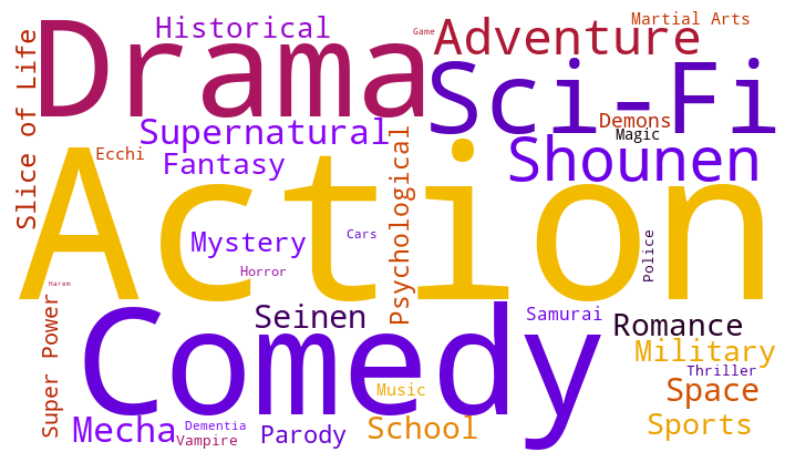

,eng_version,Genres
3971,Fullmetal Alchemist:Brotherhood,"Action, Military, Adventure, Comedy, Drama, Magic, Fantasy, Shounen"
9913,Gintama Season 4,"Action, Comedy, Historical, Parody, Samurai, Sci-Fi, Shounen"
6474,Hunter x Hunter,"Action, Adventure, Fantasy, Shounen, Super Power"
6006,Gintama Season 2,"Action, Sci-Fi, Comedy, Historical, Parody, Samurai, Shounen"
741,Legend of the Galactic Heroes,"Military, Sci-Fi, Space, Drama"
...,...,...
2575,Shootfighter Tekken,"Action, Martial Arts, Shounen"
8064,Samurai Flamenco,"Action, Comedy, Parody, Super Power"
510,Venus Wars,"Action, Sci-Fi, Adventure, Space"
6864,Saint Seiya Omega,"Action, Adventure, Fantasy, Shounen"


In [146]:
get_user_preferences(11880 , rating_df, df , plot=True)

In [147]:
def get_user_recommendations(similar_users , user_pref ,df , synopsis_df, rating_df, n=10):

    recommended_animes = []
    anime_list = []

    for user_id in similar_users.similar_users.values:
        pref_list = get_user_preferences(int(user_id) , rating_df, df)

        pref_list = pref_list[~pref_list.eng_version.isin(user_pref.eng_version.values)]

        if not pref_list.empty:
            anime_list.append(pref_list.eng_version.values)

    if anime_list:
            anime_list = pd.DataFrame(anime_list)

            sorted_list = pd.DataFrame(pd.Series(anime_list.values.ravel()).value_counts()).head(n)

            for i,anime_name in enumerate(sorted_list.index):
                n_user_pref = sorted_list[sorted_list.index == anime_name].values[0][0]

                if isinstance(anime_name,str):
                    frame = getAnimeFrame(anime_name,df)
                    anime_id = frame.anime_id.values[0]
                    genre = frame.Genres.values[0]
                    synopsis = getSynopsis(int(anime_id),synopsis_df)

                    recommended_animes.append({
                        "n" : n_user_pref,
                        "anime_name" : anime_name,
                        "Genres" : genre,
                        "Synopsis": synopsis
                    })
    return pd.DataFrame(recommended_animes).head(n)

In [148]:
similar_users =find_similar_users(int(11880),user_weights,user2user_encoded,user2user_decoded)

In [149]:
user_pref = get_user_preferences(11880 , rating_df, df , plot=False)

In [150]:
get_user_recommendations(similar_users,user_pref,df, synopsis_df,rating_df,n=1)

,n,anime_name,Genres,Synopsis
0,10,Nisekoi:False Love,"Harem, Comedy, Romance, School, Shounen","aku Ichijou, a first-year student at Bonyari High School, is the sole heir to an intimidating yakuza family. Ten years ago, Raku made a promise to his childhood friend. Now, all he has to go on is a pendant with a lock, which can only be unlocked with the key which the girl took with her when they parted. Now, years later, Raku has grown into a typical teenager, and all he wants is to remain as uninvolved in his yakuza background as possible while spending his school days alongside his middle school crush Kosaki Onodera. However, when the American Bee Hive Gang invades his family's turf, Raku's idyllic romantic dreams are sent for a toss as he is dragged into a frustrating conflict: Raku is to pretend that he is in a romantic relationship with Chitoge Kirisaki, the beautiful daughter of the Bee Hive's chief, so as to reduce the friction between the two groups. Unfortunately, reality could not be farther from this whopping lie—Raku and Chitoge fall in hate at first sight, as the girl is convinced he is a pathetic pushover, and in Raku's eyes, Chitoge is about as attractive as a savage gorilla. Nisekoi follows the daily antics of this mismatched couple who have been forced to get along for the sake of maintaining the city's peace. With many more girls popping up his life, all involved with Raku's past somehow, his search for the girl who holds his heart and his promise leads him in more unexpected directions than he expects."


### HYBRID RECOMMENDER SYSTEM

In [151]:
def hybrid_recommendation(user_id , user_weight=0.5, content_weight =0.5):

    ## User Recommndation

    similar_users =find_similar_users(user_id,user_weights,user2user_encoded,user2user_decoded)
    user_pref = get_user_preferences(user_id , rating_df, df)
    user_recommended_animes =get_user_recommendations(similar_users,user_pref,df, synopsis_df,rating_df)
    

    user_recommended_anime_list = user_recommended_animes["anime_name"].tolist()
    print(user_recommended_anime_list)

    #### Content recommendation
    content_recommended_animes = []

    for anime in user_recommended_anime_list:
        similar_animes = find_similar_animes(anime, anime_weights, anime2anime_encoded, anime2anime_decoded, df, synopsis_df)

        if similar_animes is not None and not similar_animes.empty:
            content_recommended_animes.extend(similar_animes["name"].tolist())
        else:
            print(f"No similar anime found {anime}")
    
    combined_scores = {}

    for anime in user_recommended_anime_list:
        combined_scores[anime] = combined_scores.get(anime,0) + user_weight

    for anime in content_recommended_animes:
        combined_scores[anime] = combined_scores.get(anime,0) + content_weight  

    sorted_animes = sorted(combined_scores.items() , key=lambda x:x[1] , reverse=True)

    return [anime for anime , score in sorted_animes[:10]] 

In [152]:
hybrid_recommendation(11880)

['Nisekoi:False Love', 'Blue Exorcist', 'Angel Beats!', 'Your Lie in April', 'Toradora!', 'High School DxD', 'The Seven Deadly Sins', 'Charlotte', 'The Pet Girl of Sakurasou', 'No Game, No Life']


['High School DxD',
 'Cyborg Kuro-chan',
 'Mac the Movie',
 'Nisekoi:False Love',
 'Blue Exorcist',
 'Angel Beats!',
 'Your Lie in April',
 'Toradora!',
 'The Seven Deadly Sins',
 'Charlotte']